# Reproducing the reference solution

For a bit of context, this notebook aims to reproduce the reference solution in figure 1 of [the original paper](https://arxiv.org/pdf/2205.04611). 

Figure 1 solves the 1D wave equation,

$$\frac 1 {c^2} u_{tt} = u_xx,$$

with $c = 1$. 

To reproduce the reference solution, we can just use [d'Alembert's solution](https://en.wikipedia.org/wiki/D%27Alembert%27s_formula):

$$u(x, t) = \frac 1 2 [f(x + ct) + f(x - ct)] + \frac 1 2 \int^{x + ct}_{x - ct} g(s).$$

Here, $f(x) = u(x, 0)$ is the initial displacement, and $g(x) = u_t(x, 0)$ is the initial velocity.

This is exactly what the paper does. See [here](https://github.com/cselab/odil/blob/main/examples/wave/wave.py) for reference.

Note they choose 

$$f(x) = \cos(k(x \pm ct - 0.5)),\,\,\,\ g(x) = 0.$$

The $g = 0$ means that we get a pure standing wave with no integral term. They sum over $k = [\pi, 2\pi, 3\pi, 4\pi, 5\pi]$ to superimpose 5 harmonics as the initial profile. They also normalise by the number of entires in the $k$ list to bound the results.

More formally, the initial conditions for $u$ and $u_t$ and Dirichlet conditions are specified from an exact solution 

$$u(x, t) = \sum^5_{k = 1} \left( \cos(x - t + 0.5) \right)k\pi + \left( \cos(x + t + 0.5) \right)k\pi,$$

in a rectangular domain $x \in (-1, 1),\ t \in (0, 1)$.

This should be pretty easy to code up.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [194]:
# get d'Alemberts exact solution of the 1D wave equation
def get_exact(tt: np.ndarray, x: np.ndarray) -> np.ndarray:
    u = np.zeros((tt.size, x.size)) # solution vector

    # solve for all t
    for t_idx, t in enumerate(tt):
        ii = [1, 2, 3, 4, 5]
        # compute harmonics
        for i in ii:
            k = i * np.pi
            u[t_idx] += np.cos((x - t + 0.5) * k)  # leftward
            u[t_idx] += np.cos((x + t - 0.5) * k)  # rightward
        
    u /= 2 * len(ii)  # 1/10 prefactor from the paper
    return u

In [207]:
t = np.linspace(0, 1, 200)
x = np.linspace(-1, 1, 200)

u = get_exact(t, x)

In [208]:
def plot(uu: np.ndarray, xx: np.ndarray, tt:np.ndarray) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))

    im = ax.imshow(
        uu,
        extent=[xx.min(), xx.max(), tt.max(), tt.min()],  # [xmin, xmax, tmax, tmin]
        cmap='RdBu_r',
        vmin=-0.5, vmax=0.5,  # symmetric since u is bounded in [-0.5, 0.5]
        aspect = 4
    )

    plt.colorbar(im, ax=ax, label='u(x, t)')
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_title('Exact solution')
    plt.tight_layout()
    plt.show()

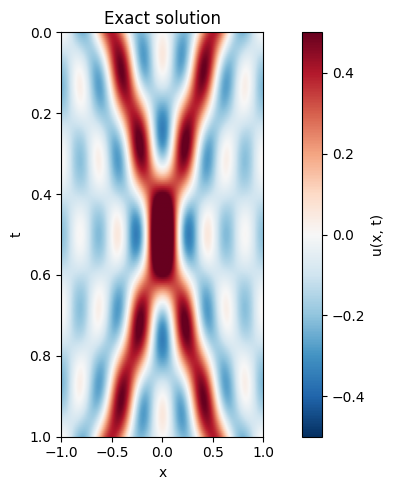

In [209]:
plot(u, x, t)